<div style="text-align:center; background:#2e2e2e; padding:32px 20px">
    <div style="font-size:46px; font-weight:bold; color:#f4f4ef; letter-spacing:4px; text-transform:uppercase">
        Sanghelios
    </div>
    <div style="font-size:17px; color:#888; margin-top:10px; letter-spacing:3px; text-transform:uppercase">
        Parte 1 — EDA y Preprocesamiento
    </div>
    <div style="font-size:17px; color:#666; margin-top:14px; letter-spacing:1px">
        Autor: Jerónimo Hoyos Botero &nbsp;|&nbsp; Creado: Mayo 2026 &nbsp;|&nbsp; Última actualización: Mayo 2026
    </div>
</div>

<div style="background:#2e2e2e; color:#f4f4ef; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border-left:3px solid #888">
    Configuración
</div>

<div style="background:#f5f3e8; padding:12px 16px; border:0.5px solid #d8d3b8; border-radius:4px; font-size:16px; color:#555240">
    <b> Ajustes del notebook </b>
</div>

In [107]:
# Automatically reload local modules before each cell run
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<div style="background:#f5f3e8; padding:12px 16px; border:0.5px solid #d8d3b8; border-radius:4px; font-size:16px; color:#555240">
    <b> Importaciones </b>
</div>

In [108]:
# Data manipulation
import pandas as pd
import numpy as np


# Data visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display
import missingno as msno
# Import zscore function
from scipy.stats import zscore
import numpy as np
# Utils
import math
import re
import unicodedata
from pyod.models.mad import MAD

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


<div style="background:#2e2e2e; color:#f4f4ef; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border-left:3px solid #888">
    Carga de Datos
</div>

<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    <b> Cargar los datos mediante los csv descargados. </b>
</div>

In [109]:
paths = {
    "banco_sangre": r"..\data\raw\banco_sangre.csv",
    "defunciones": r"..\data\raw\defunciones.csv",
    "atenciones": r"..\data\raw\atenciones.csv"
}

dataframes = {}

for var_name, file in paths.items():
    print(f"Loading data from: {file}")
    try:
        dataframes[var_name] = pd.read_csv(file, low_memory=False)
        print(f"'{var_name}' loaded successfully. Shape: {dataframes[var_name].shape}")
    except FileNotFoundError:
        print(f"Error: File not found → {file}")
        dataframes[var_name] = None
    except pd.errors.EmptyDataError:
        print("Error: The file is empty.")
        dataframes[var_name] = None
    except pd.errors.ParserError:
        print("Error: The file content could not be parsed.")
        dataframes[var_name] = None
    except PermissionError:
        print("Error: Permission denied when accessing the file.")
        dataframes[var_name] = None
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        dataframes[var_name] = None

# Asignar a variables individuales
df_banco_sangre = dataframes["banco_sangre"]
df_defunciones  = dataframes["defunciones"]
df_atenciones   = dataframes["atenciones"]

print("\nDimensiones de los DataFrames:")
print("Banco:      ", df_banco_sangre.shape)
print("Defunciones:", df_defunciones.shape)
print("Atenciones:", df_atenciones.shape)

# Limpiar memoria
del dataframes

Loading data from: ..\data\raw\banco_sangre.csv
'banco_sangre' loaded successfully. Shape: (35840, 11)
Loading data from: ..\data\raw\defunciones.csv
'defunciones' loaded successfully. Shape: (5094, 26)
Loading data from: ..\data\raw\atenciones.csv
'atenciones' loaded successfully. Shape: (221203, 12)

Dimensiones de los DataFrames:
Banco:       (35840, 11)
Defunciones: (5094, 26)
Atenciones: (221203, 12)


<div style="background:#2e2e2e; color:#f4f4ef; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border-left:3px solid #888">
    Preparación de Datos
</div>

<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    <b> Funciones para el ajuste de los 3 dataframes. </b>
</div>

In [110]:
def explorar_df(nombre, df):
    print(f"\n{nombre}  —  {df.shape[0]:,} filas × {df.shape[1]} columnas")

    info = pd.DataFrame({
        "dtype":   df.dtypes.astype(str),
        "nulos":   df.isna().sum(),
        "% nulos": (df.isna().mean()*100).round(1),
        **{f"ej {i+1}": df.iloc[i] for i in range(min(5, len(df)))},
    })

    display(info)

In [111]:
def estandarizar_columnas(df):
    def limpiar(col):
        col = unicodedata.normalize("NFKD", col)
        col = col.encode("ascii", "ignore").decode() 
        col = col.strip().lower()
        col = re.sub(r"[^a-z0-9\s]", " ", col)       
        col = re.sub(r"\s+", "_", col).strip("_")    
        return col

    nuevos = {col: limpiar(col) for col in df.columns}
    for viejo, nuevo in nuevos.items():
        if viejo != nuevo:
            print(f"  {viejo!r:35} → {nuevo!r}")

    return df.rename(columns=nuevos)

In [112]:
def estandarizar_etiquetas(etiqueta):
    if pd.isna(etiqueta):
        return etiqueta  
    return (
        str(etiqueta)
        .strip()
        .lower()
        .replace("-", "_")
        .replace("/", "_")
        .replace(" ", "_")
    )

In [113]:
def boxplots_numericas(df):
    numericas = df.select_dtypes(include="number").columns
    n = len(numericas)
    fig, axes = plt.subplots(1, n, figsize=(n * 3, 4))

    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, numericas):
        ax.boxplot(df[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor="#d0e7fa"),
                   medianprops=dict(color="#185FA5", linewidth=2))
        ax.set_title(col, fontsize=9)
        ax.tick_params(labelsize=7)
        ax.set_xticks([]) 
    plt.tight_layout()
    plt.show()


In [114]:
def histogramas_numericas(df):
    numericas = df.select_dtypes(include="number").columns
    n = len(numericas)
    fig, axes = plt.subplots(1, n, figsize=(n * 3, 4))

    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, numericas):
        ax.hist(df[col].dropna(), bins=30, color="#d0e7fa",
                edgecolor="#185FA5", linewidth=0.5)
        ax.set_title(col, fontsize=9)
        ax.tick_params(labelsize=7)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

<div style="background:#2e2e2e; color:#f4f4ef; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border-left:3px solid #888">Bancos de Sangre</div>

<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    Exploración general para ver problemas obvios del dataframe.
</div>

In [115]:
explorar_df("Banco", df_banco_sangre)


Banco  —  35,840 filas × 11 columnas


,dtype,nulos,% nulos,ej 1,ej 2,ej 3,ej 4,ej 5
ANO,int64,0,0.0,2020,2020,2020,2020,2020
TRIMESTRE,int64,0,0.0,4,1,1,1,1
FECHA EXTRACCION,str,0,0.0,28/12/2020,01/02/2020,01/02/2020,01/02/2020,01/02/2020
RH,str,41,0.1,0+,0+,0+,0+,0+
BARRIO,str,7788,21.7,POPULAR 1,20 DE JULIO,20 DE JULIO,20 DE JULIO,20 DE JULIO
CIUDAD,str,0,0.0,MEDELLIN,MEDELLIN,MEDELLIN,MEDELLIN,MEDELLIN
EDAD,float64,2,0.0,41.0,43.0,43.0,44.0,44.0
ESTATURA,float64,79,0.2,NaN,1.74,1.74,1.6,1.6
FECHA NACIMIENTO,str,2,0.0,1982 Jan 01 12:00:00 AM,1979 Mar 12 12:00:00 AM,1979 Mar 12 12:00:00 AM,1979 Apr 21 12:00:00 AM,1979 Apr 21 12:00:00 AM
PESO,float64,41,0.1,NaN,80.0,80.0,86.0,86.0


In [116]:
# Conteo de los niveles en las diferentes columnas categóricas
cols_cat = ["RH","BARRIO","CIUDAD","SEXO"]

for col in cols_cat:
    print(f'Columna {col}: {df_banco_sangre[col].nunique()} subniveles')

Columna RH: 8 subniveles
Columna BARRIO: 1274 subniveles
Columna CIUDAD: 28 subniveles
Columna SEXO: 2 subniveles


<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    Todas las columnas categóricas tienen más de 1 subnivel.
</div>

In [117]:
df_banco_sangre.describe()

,ANO,TRIMESTRE,EDAD,ESTATURA,PESO
count,35840.000000,35840.000000,35838.000000,35761.000000,35799.000000
mean,2021.828599,2.387249,37.713070,1.663522,73.329004
std,1.569845,1.118653,12.497798,0.089134,13.517872
min,2020.000000,1.000000,14.000000,1.000000,50.000000
25%,2021.000000,1.000000,27.000000,1.600000,63.000000
50%,2022.000000,2.000000,36.000000,1.660000,72.000000
75%,2023.000000,3.000000,47.000000,1.730000,81.000000
max,2025.000000,4.000000,104.000000,2.030000,171.000000


<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    Todas las columnas numéricas tienen desviaciones estándar ("std") diferentes de cero, lo que indica que no tienen un único valor.
</div>

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Estandarizando nombres y etiquetas
</div>

In [118]:
df_banco_sangre = estandarizar_columnas(df_banco_sangre)

  'ANO'                               → 'ano'
  'TRIMESTRE'                         → 'trimestre'
  'FECHA EXTRACCION'                  → 'fecha_extraccion'
  'RH'                                → 'rh'
  'BARRIO'                            → 'barrio'
  'CIUDAD'                            → 'ciudad'
  'EDAD'                              → 'edad'
  'ESTATURA'                          → 'estatura'
  'FECHA NACIMIENTO'                  → 'fecha_nacimiento'
  'PESO'                              → 'peso'
  'SEXO'                              → 'sexo'


In [119]:
# Define categorical columns to standardize labels
columnas_para_estandarizar = ["barrio", "ciudad", "sexo"]

# Apply standardization of categorical labels
for index in columnas_para_estandarizar:
    df_banco_sangre[index] = df_banco_sangre[index].apply(estandarizar_etiquetas)

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Manejo de Duplicados
</div>

In [120]:
exactos = df_banco_sangre.duplicated().sum()
por_nacimiento_extraccion_rh = df_banco_sangre.duplicated(
    subset=["fecha_nacimiento", "fecha_extraccion", "rh"]
).sum()
total = len(df_banco_sangre)

resumen = pd.DataFrame({
    "Tipo de duplicado": ["Exactos (todas las columnas)", "Por fecha_nacimiento + fecha_extraccion + rh"],
    "Cantidad": [exactos, por_nacimiento_extraccion_rh],
    "%": [round(exactos / total * 100, 1), round(por_nacimiento_extraccion_rh / total * 100, 1)]
})

resumen

,Tipo de duplicado,Cantidad,%
0,Exactos (todas las columnas),1622,4.5
1,Por fecha_nacimiento + fecha_extraccion + rh,1746,4.9


<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    Se encontraron <b>4.5%</b> de duplicados totales y <b>4.9%</b> duplicados por  fecha_nacimiento + fecha_extraccion + rh. Dada la baja probabilidad de estos duplicados serán eliminados.
</div>

In [121]:
df_banco_sangre = df_banco_sangre.drop_duplicates(subset=["fecha_nacimiento", "fecha_extraccion", "rh"])

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Selección de Variables
</div>

<div style="background:#f7f7f3; padding:16px 20px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:15px; color:#2e2e2e">
    La siguiente tabla muestra que variables usaremos para el proyecto: <br> <br>
    <table style="width:100%; border-collapse:collapse; font-size:13px;">
        <thead>
            <tr style="background:#2e2e2e; color:#f4f4ef;">
                <th style="text-align:left; padding:8px 10px; font-weight:500;">Variable</th>
                <th style="text-align:left; padding:8px 10px; font-weight:500;">Descripción</th>
                <th style="text-align:center; padding:8px 10px; font-weight:500;">Incluir</th>
                <th style="text-align:left; padding:8px 10px; font-weight:500;">Justificación</th>
            </tr>
        </thead>
        <tbody>
            <tr style="border-bottom:0.5px solid #e8e8e4; background:#fafaf9;">
                <td style="padding:7px 10px;">Año</td>
                <td style="padding:7px 10px;">Año de la donación</td>
                <td style="text-align:center; padding:7px 10px;">✗</td>
                <td style="padding:7px 10px;">Redundante con Fecha Extracción, de la cual se puede derivar.</td>
            </tr>
            <tr style="border-bottom:0.5px solid #e8e8e4;">
                <td style="padding:7px 10px;">Trimestre</td>
                <td style="padding:7px 10px;">Trimestre de la donación</td>
                <td style="text-align:center; padding:7px 10px;">✗</td>
                <td style="padding:7px 10px;">Derivable de Fecha Extracción; puede re-crearse en feature engineering.</td>
            </tr>
            <tr style="border-bottom:0.5px solid #e8e8e4; background:#fafaf9;">
                <td style="padding:7px 10px;">Fecha Extracción</td>
                <td style="padding:7px 10px;">Fecha de la donación</td>
                <td style="text-align:center; padding:7px 10px;">✓</td>
                <td style="padding:7px 10px;">Permite identificar estacionalidad y tendencias de volumen a lo largo del tiempo.</td>
            </tr>
            <tr style="border-bottom:0.5px solid #e8e8e4;">
                <td style="padding:7px 10px;">RH</td>
                <td style="padding:7px 10px;">Grupo y factor RH del donante</td>
                <td style="text-align:center; padding:7px 10px;">✓</td>
                <td style="padding:7px 10px;">Determina compatibilidad; esencial para modelar escasez por tipo de sangre.</td>
            </tr>
            <tr style="border-bottom:0.5px solid #e8e8e4; background:#fafaf9;">
                <td style="padding:7px 10px;">Barrio</td>
                <td style="padding:7px 10px;">Barrio de residencia del donante</td>
                <td style="text-align:center; padding:7px 10px;">✓</td>
                <td style="padding:7px 10px;">Permite segmentar geográficamente el perfil del donante e identificar zonas de alta/baja donación.</td>
            </tr>
            <tr style="border-bottom:0.5px solid #e8e8e4;">
                <td style="padding:7px 10px;">Ciudad</td>
                <td style="padding:7px 10px;">Ciudad de residencia del donante</td>
                <td style="text-align:center; padding:7px 10px;">✓</td>
                <td style="padding:7px 10px;">Permite analizar patrones de donación a nivel de ciudad y proyectar volumen por región.</td>
            </tr>
            <tr style="border-bottom:0.5px solid #e8e8e4; background:#fafaf9;">
                <td style="padding:7px 10px;">Edad</td>
                <td style="padding:7px 10px;">Edad del donante al momento de la donación</td>
                <td style="text-align:center; padding:7px 10px;">✓</td>
                <td style="padding:7px 10px;">Variable clave del perfil del donante.</td>
            </tr>
            <tr style="border-bottom:0.5px solid #e8e8e4;">
                <td style="padding:7px 10px;">Fecha Nacimiento</td>
                <td style="padding:7px 10px;">Fecha de nacimiento del donante</td>
                <td style="text-align:center; padding:7px 10px;">✗</td>
                <td style="padding:7px 10px;">Redundante con Edad.</td>
            </tr>
            <tr style="border-bottom:0.5px solid #e8e8e4; background:#fafaf9;">
                <td style="padding:7px 10px;">Peso</td>
                <td style="padding:7px 10px;">Peso del donante en kg</td>
                <td style="text-align:center; padding:7px 10px;">✓</td>
                <td style="padding:7px 10px;">Determina el volumen máximo extraíble por donación; relevante para estimar disponibilidad real de sangre.</td>
            </tr>
            <tr style="border-bottom:0.5px solid #e8e8e4;">
                <td style="padding:7px 10px;">Estatura</td>
                <td style="padding:7px 10px;">Estatura del donante en cm</td>
                <td style="text-align:center; padding:7px 10px;">✓</td>
                <td style="padding:7px 10px;">Junto con el peso permite calcular el IMC.</td>
            </tr>
            <tr>
                <td style="padding:7px 10px;">Sexo</td>
                <td style="padding:7px 10px;">Sexo biológico del donante</td>
                <td style="text-align:center; padding:7px 10px;">✓</td>
                <td style="padding:7px 10px;">Variable clave del perfil del donante.</td>
            </tr>
        </tbody>
    </table>
</div>

In [122]:
columnas_originales_seleccionadas = ['fecha_extraccion', 'rh', 'barrio', 'ciudad','edad', 'estatura', 'peso', 'sexo']
df_banco_sangre = df_banco_sangre[columnas_originales_seleccionadas]

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Filtrado de Población Objetivo
</div>

<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    Los requisitos para donar sangre según la <a href="https://www.cruzrojacolombiana.org/banco-de-sangre/dona-sangre" target="_blank" rel="noopener noreferrer">Cruz Roja Colombiana</a> son:
    <ul style="margin:8px 0 0 20px;">
        <li style="margin:4px 0;">Pesar más de 50 kg</li>
        <li style="margin:4px 0;">Edad entre 18 y 65 años</li>
    </ul>
</div>

In [123]:
df_banco_sangre = df_banco_sangre[
    (df_banco_sangre["peso"] > 50) &
    (df_banco_sangre["edad"] >= 18) &
    (df_banco_sangre["edad"] <= 65)
].copy()

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Manejo de tipos de datos
</div>

<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    Se van identificar los tipos de datos no adecuados.
</div>

In [124]:
df_banco_sangre.dtypes

fecha_extraccion        str
rh                      str
barrio                  str
ciudad                  str
edad                float64
estatura            float64
peso                float64
sexo                    str
dtype: object

In [125]:
# Un formato estandar para fechas y asegurarnos que edad es un entero
df_banco_sangre["fecha_extraccion"] = pd.to_datetime(df_banco_sangre["fecha_extraccion"], format="%d/%m/%Y").dt.date
df_banco_sangre["edad"] = df_banco_sangre["edad"].astype(int)

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Manejo de errores tipográficos en variables categóricos
</div>

<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    Se analizará si existen subniveles con diferente nombre pero mismo significado, excluyendo barrio debido a su alta cantidad de nombres distintos.
</div>

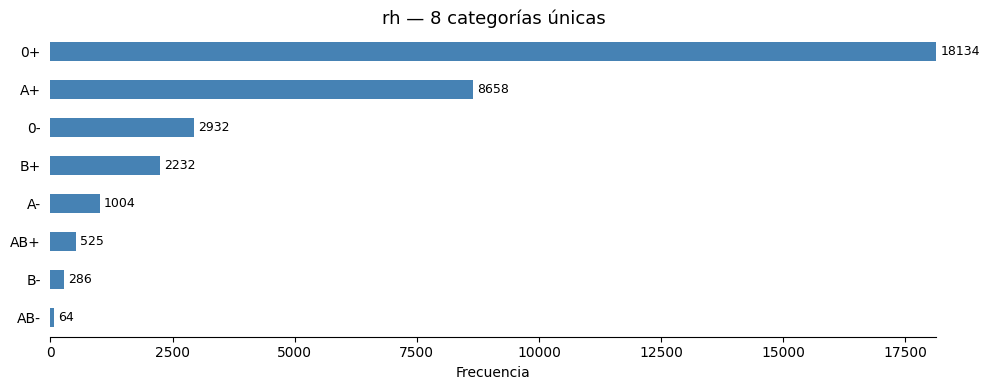

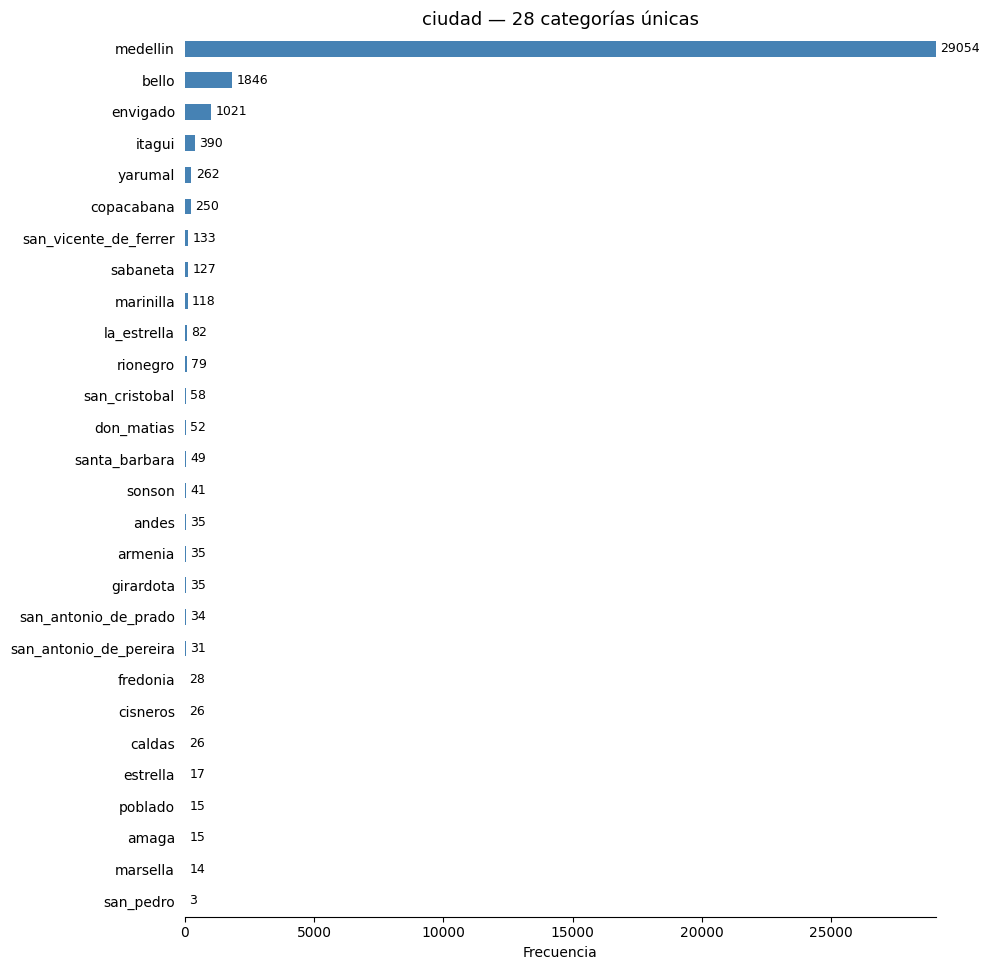

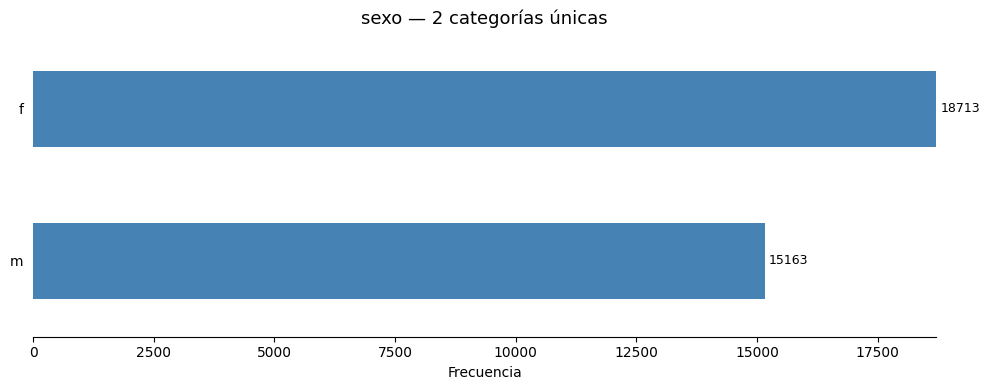

In [126]:
cols_cat = ['rh', 'ciudad', 'sexo']

for col in cols_cat:
    conteo = df_banco_sangre[col].value_counts().sort_values(ascending=True) 
    n = len(conteo)
    
    fig, ax = plt.subplots(figsize=(10, max(4, n * 0.35)))
    conteo.plot(kind='barh', ax=ax, color='steelblue')
    
    ax.set_title(f'{col} — {n} categorías únicas', fontsize=13)
    ax.set_xlabel('Frecuencia')
    ax.set_ylabel('')
    ax.bar_label(ax.containers[0], padding=3, fontsize=9)
    
    # Quitar márgenes
    ax.margins(0)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(left=False)
    
    plt.tight_layout()
    plt.show()

<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    No se encontraron inconsistencias y se segmentó solo por la ciudad de Medellín.
</div>

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Manejo de datos atipicos
</div>

In [127]:
# Conteo de ceros por columna
cols = df_banco_sangre[df_banco_sangre == 0].count(axis=0)
cols[cols > 0]

Series([], dtype: int64)

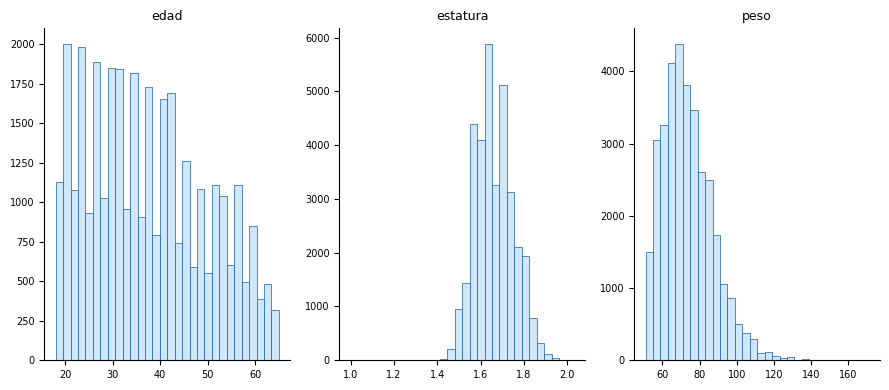

In [128]:
histogramas_numericas(df_banco_sangre)

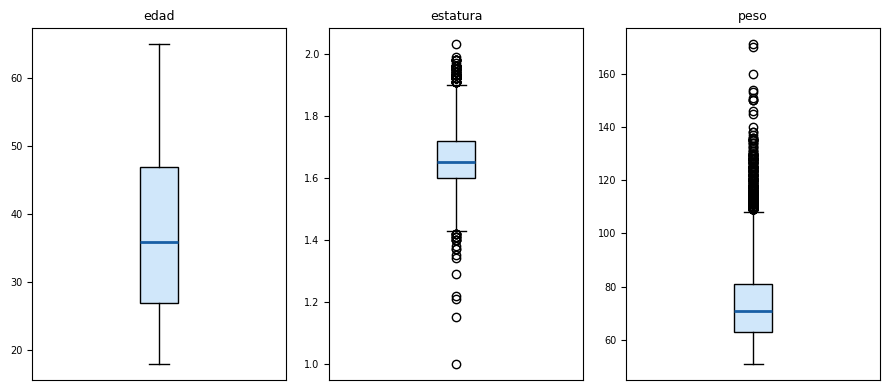

In [129]:
boxplots_numericas(df_banco_sangre)

In [130]:
# Z-score clásico
print("Z-score clásico")
for col in ["edad", "peso", "estatura"]:
    z = np.abs(zscore(df_banco_sangre[col].dropna()))
    print(f"  {col}: {(z > 3).sum()} outliers")

# Z-score modificado
print("\nZ-score modificado")
for col in ["edad", "peso", "estatura"]:
    mad = MAD(threshold=3.5)
    labels = mad.fit(df_banco_sangre[col].dropna().values.reshape(-1, 1)).labels_
    print(f"  {col}: {labels.sum()} outliers")

# IQR
print("\nIQR")
for col in ["edad", "peso", "estatura"]:
    Q1 = df_banco_sangre[col].quantile(0.25)
    Q3 = df_banco_sangre[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df_banco_sangre[col] < Q1 - 1.5 * IQR) |
         (df_banco_sangre[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col}: {n} outliers")

Z-score clásico
  edad: 0 outliers
  peso: 306 outliers
  estatura: 48 outliers

Z-score modificado
  edad: 0 outliers
  peso: 201 outliers
  estatura: 15 outliers

IQR
  edad: 0 outliers
  peso: 540 outliers
  estatura: 111 outliers


In [131]:
mask = np.ones(len(df_banco_sangre), dtype=bool)

for col in ["peso", "estatura"]:
    mad = MAD(threshold=3.5)
    col_data = df_banco_sangre[col].dropna()
    labels = mad.fit(col_data.values.reshape(-1, 1)).labels_
    # Usar posiciones en vez de índices
    outlier_positions = np.where(labels == 1)[0]
    mask[outlier_positions] = False

df_banco_sangre = df_banco_sangre.iloc[mask]
print(f"Registros restantes: {len(df_banco_sangre):,}")

Registros restantes: 33,660


<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Manejo de datos faltantes
</div>

In [132]:
total = len(df_banco_sangre)
missing = df_banco_sangre.isna().sum()

pd.DataFrame({
    "Faltantes": missing,
    "%": (missing / total * 100).round(1)
}).sort_values("Faltantes", ascending=False)

,Faltantes,%
barrio,7588,22.5
rh,41,0.1
estatura,37,0.1
fecha_extraccion,0,0.0
ciudad,0,0.0
edad,0,0.0
peso,0,0.0
sexo,0,0.0


In [133]:
df_banco_sangre = df_banco_sangre.dropna(subset=["rh", "estatura"])

<Axes: >

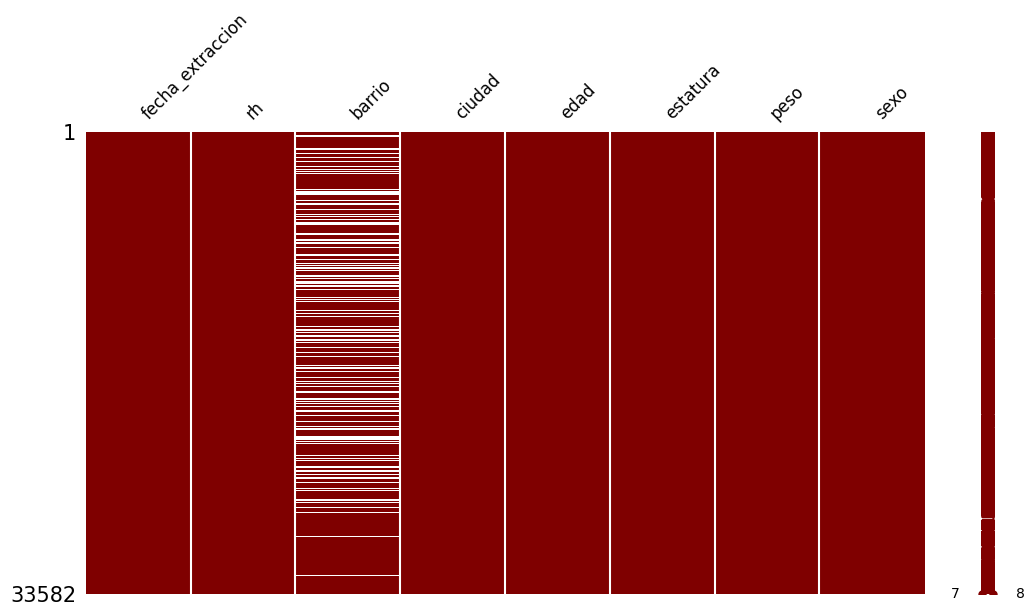

In [134]:
sorted_df = df_banco_sangre.sort_values('fecha_extraccion')
msno.matrix(sorted_df, figsize=(12, 6), fontsize=12, color=[0.5, 0, 0])

In [135]:
df_banco_sangre = df_banco_sangre.dropna(subset=["barrio"])

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Ingeniería de Características 
</div>

<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    Se creará la variable <b>cobertura</b>, que representa el porcentaje de la población que puede recibir sangre de un donante según su tipo sanguíneo y las reglas de compatibilidad ABO/Rh. Los porcentajes de distribución poblacional provienen del estudio <a href="https://dialnet.unirioja.es/descarga/articulo/8741610.pdf" target="_blank" rel="noopener noreferrer">Ramírez-González et al. (2014)</a>, realizado con 87.481 donantes del Hospital Pablo Tobón Uribe de Medellín entre 2000 y 2009.
</div>

In [136]:
# Distribución poblacional colombiana
dist_poblacion = {
    "0+":  52.1,
    "A+":  28.0,
    "B+":   7.0,
    "0-":   6.7,
    "A-":   3.5,
    "B-":   1.7,
    "AB+":  0.8,
    "AB-":  0.3,
}

# Cobertura: % de población que puede recibir cada tipo
cobertura_map = {
    "0-":  100.0,  # ← dona a todos, simplemente es 100%
    "0+":  sum([dist_poblacion[k] for k in ["0+", "A+", "B+", "AB+"]]),
    "A-":  sum([dist_poblacion[k] for k in ["A+", "A-", "AB+", "AB-"]]),
    "A+":  sum([dist_poblacion[k] for k in ["A+", "AB+"]]),
    "B-":  sum([dist_poblacion[k] for k in ["B+", "B-", "AB+", "AB-"]]),
    "B+":  sum([dist_poblacion[k] for k in ["B+", "AB+"]]),
    "AB-": sum([dist_poblacion[k] for k in ["AB+", "AB-"]]),
    "AB+": sum([dist_poblacion[k] for k in ["AB+"]]),
}

# Agregamos ambas columnas al DataFrame basándonos en el 'rh'
df_banco_sangre["cobertura"] = df_banco_sangre["rh"].map(cobertura_map)
df_banco_sangre["pct_poblacion"] = df_banco_sangre["rh"].map(dist_poblacion)

# Agrupamos para obtener los valores únicos por cada RH presente en tu DataFrame
resultado = df_banco_sangre.groupby("rh")[["pct_poblacion", "cobertura"]].first().sort_values("pct_poblacion", ascending=False)

print(f"{'RH':<5} | {'% Población Col.':<16} | {'% Cobertura':<26}")
print("-" * 55)
for sangre, filas in resultado.iterrows():
    print(f"{sangre:<5} | {filas['pct_poblacion']:>14.1f}% | {filas['cobertura']:>23.1f}%")

RH    | % Población Col. | % Cobertura               
-------------------------------------------------------
0+    |           52.1% |                    87.9%
A+    |           28.0% |                    28.8%
B+    |            7.0% |                     7.8%
0-    |            6.7% |                   100.0%
A-    |            3.5% |                    32.6%
B-    |            1.7% |                     9.8%
AB+   |            0.8% |                     0.8%
AB-   |            0.3% |                     1.1%


<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    Se creará la variable <b>imc</b> a partir del peso y la estatura del donante, reemplazando ambas variables por un único indicador clínico.
</div>

In [137]:
# Calcular IMC
df_banco_sangre["imc"] = (df_banco_sangre["peso"] / (df_banco_sangre["estatura"] ** 2)).round(2)

# Eliminar estatura
df_banco_sangre = df_banco_sangre.drop(columns=["estatura","peso"])

<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    Se creará la variable <b>comuna</b> únicamente para los donantes de Medellín, asignando <b>no_aplica</b> al resto de municipios dado que no comparten el mismo esquema de división territorial.
</div>

In [138]:
print(df_banco_sangre["barrio"].unique().tolist())

['20_de_julio', 'cataluna', 'villatina', 'laureles', 'santa_catalina', 'san_cristobal', 'las_vegas', 'santa_monica', '12_de_octubre', 'la_milagrosa', 'sabaneta', 'jardines', 'ancon_1', 'la_finca', 'san_javier', 'llano_santafe_de_antioquia', 'salvador', 'guasimalito', 'alfonso_lopez', 'pueblo_viejo', 'el_vergel', 'el_remanso', 'belen_san_bernardo', 'calatrava', 'cabanas', 'floresta_alcazares', 'belen', 'san_pio', 'belen_las_mercedes', 'centro', 'calazans', 'manrique', 'popular_#_2', 'boston', 'la_america', 'calasanz', 'manrique_oriental', 'porvenir', 'santa_cruz', 'perez', 'milagrosa', 'pontevedra', 'belen_altavista', 'abreito', 'centro.', 'limonar_2', 'conquistadores', 'sucre', 'caicedo', 'caicedo_villa_liliam', 'san_rafael', 'robledo', 'los_bernal', 'colinas_de_enciso', 'san_diego', 'las_antillas', 'boyaca_las_brisas', 'la_floresta', 'guayabal', 'travesias', 'envigado_parque', 'buenos_aires', 'madera', 'ducado', 'la_castellana', 'la_magnolia', 'la_mina', 'playita', 'belen_fatima', 'pl

In [139]:
barrios_por_comuna = {
    "1 - Popular": [
        "popular_1", "popular_#_2", "granizal", "carpinelo", "santo_domingo",
        "bello_oriente", "villa_guadalupe", "la_avanzada", "la_honda",
        "la_esperanza", "villa_del_socorro", "picacho", "picachito", "mirador",
        "aldea_verde", "las_granjas", "nuevo_horizonte", "pradera_alta",
        "santo_domigo_savio",
    ],
    "2 - Santa Cruz": [
        "santa_cruz", "santa_cruz_la_rosa", "villa_niza", "la_isla", "el_pinal",
        "orquidea", "la_frontera", "la_inmaculada", "san_jose_la_cima",
        "las_esmeraldas", "campo_valdes", "manrique_las_nieves", "la_rosa",
        "palermo",
    ],
    "3 - Manrique": [
        "manrique", "manrique_oriental", "manrrique_oriental", "manrique_central",
        "manrique_guadalupe", "manrique_la_salle", "manrique_las_nieves",
        "manrique_la_cruz", "manrrique_la_cruz", "manrrique_jardin",
        "manrrique_santa_ines", "manrique_santa_ines", "manrique_san_pablo",
        "manrique_esmeraldas", "manrique_los_balsos", "enciso_pinal",
        "colinas_de_enciso", "la_salle", "versalles_1", "versalles_2",
        "la_cruz", "llanaditas", "los_mangos", "san_blas", "versalle_1",
        "manrrique_la_cruz",
    ],
    "4 - Aranjuez": [
        "aranjuez", "aranjuez__san_cayetano", "san_cayetano", "san_isidro",
        "san_pablo", "tricentenario", "pilarica", "san_bernardo", "la_paz",
        "san_martin", "camilo_torres", "florencia", "la_camila", "moravia",
        "norteamerica", "nor_america", "andalucia_la_francia", "andalucia",
        "la_francia", "pablo_sexto",
    ],
    "5 - Castilla": [
        "castilla", "floresta", "floresta_alcazares", "floresta.", "floresta_pradera",
        "floresta_la_pradera", "floresta_santa_lucia", "las_brisas",
        "boyaca_las_brisas", "la_finca", "la_finquita", "la_gabriela",
        "pedregal", "caribe", "villa_flora", "robledo_villa_flora", "tejelo",
        "girardot", "girardot.", "las_margaritas", "robledo_las_margaritas",
        "machado", "niquia", "niquia_camacol", "niquia_quitasol", "quitasol",
        "camino_verde", "tricentenario",
    ],
    "6 - Doce de Octubre": [
        "12_de_octubre", "doce_de_octubre", "el_triunfo", "el_playon", "playon",
        "el_progreso", "las_margaritas", "cabanas", "el_diamante",
        "robledo_el_diamante", "robledo_diamante", "diamante_2", "san_pedro",
        "kennedy", "robledo_kennedy", "robledo___kenedy", "robledo_kenedy",
        "juan_pablo_ii", "juan_pablo", "ocho_de_marzo", "8_de_marzo",
        "el_salado", "nuevo___el_salado", "san_javier_el_salado",
        "la_esperanza", "picachito",
    ],
    "7 - Robledo": [
        "robledo", "robledo_aurora", "robledo__aurora", "robledo_la_aurora",
        "robledo_aures", "robledo_bello_horizonte", "robledo_bello_oriente",
        "robledo_campina", "robledo_cordoba", "robledo_la_campina",
        "robledo_la_huerta", "robledo_la_pola", "robledo_margaritas",
        "robledo_miramar", "robledo_pajarito", "robledo_palenque",
        "robledo_parque", "robledo_primaveral", "robledo_puerta_del_sol",
        "robledo_santa_maria", "robledo_santa_margarita", "robledo_villa_sofia",
        "blanquizal", "la_iguana", "aures", "bosque", "la_huerta", "palenque",
        "la_pola", "la_campina", "cordoba", "pajarito", "altamira",
        "simon_bolivar", "volador", "el_bolo", "pilarica", "bello_horizonte",
        "calazans", "zuniga", "mirador_ce_calazans", "la_paralela", "paralela",
    ],
    "8 - Villa Hermosa": [
        "villa_hermosa", "villahermosa", "la_ladera", "la_loma", "los_angeles",
        "la_sierra", "enciso", "enciso.", "enciso_espinal", "enciso_pinal",
        "llanaditas", "los_mangos", "caicedo", "caicedo_la_toma",
        "caicedo_villa_liliam", "villa_liliam", "villa_lia", "sucre",
        "sucre_boston", "miraflores", "villa_carlota", "san_miguel",
        "primero_de_mayo", "villa_tina", "villatina",
    ],
    "9 - Buenos Aires": [
        "buenos_aires", "juan_pablo", "juan_pablo_ii", "juan_xxiii",
        "olaya_herrera", "olaya", "holaya_herrera", "barrio_antioquia",
        "la_milagrosa", "milagrosa", "la_presentacion", "san_luis", "loreto",
        "bombona", "alejandro_echavarria", "velodromo", "estadio",
        "diego_echavarria", "sucre", "san_rafael", "villa_tina",
        "asomadera", "asomadera_2", "la_candelaria", "cataluna", "santa_catalina",
        "betania", "trinidad", "lourdes", "la_mansion", "los_cerros", "calazans",
    ],
    "10 - La Candelaria": [
        "centro", "centro.", "candelaria", "la_candelaria", "centro_parque",
        "prado_centro", "villanueva", "chagualo", "el_chagualo", "guayaquil",
        "naranjal", "barrio_antioquia", "colon", "plaza_colon", "san_benito",
        "la_playa", "boston", "lovaina", "la_estacion", "hospital_mental",
        "prado", "calle_nueva", "calle_del_banco", "el_calvario",
    ],
    "11 - Laureles-Estadio": [
        "laureles", "estadio", "velodromo", "carlos_e_restrepo", "las_acacias",
        "las_acasias", "conquistadores", "suramericana", "suramerica",
        "suramerica.", "la_castellana", "la_magnolia", "los_colores",
        "los_bernal", "loma_de_los_bernal", "loma_los_bernal", "simon_bolivar",
        "san_joaquin", "san_juaquin", "manila", "castropol", "villanela",
        "ferrara", "villa_aburra", "ciudad_del_rio", "cuidad_del_rio",
        "industriales", "sevilla", "pontevedra", "curazao", "holanda",
        "las_vegas", "artex", "san_german",
    ],
    "12 - La América": [
        "la_america", "los_colores", "la_floresta", "santa_monica",
        "santa_monica_#_2", "santa_lucia", "floresta_santa_lucia",
        "calasanz", "la_pradera", "la_aldea", "campo_alegre", "campo_amor",
        "guadalupe", "mandalay", "mondolay", "el_salvador", "la_mota",
        "mota_belen", "antonio_narino", "los_almendros",
    ],
    "13 - San Javier": [
        "san_javier", "san_javier_el_socorro", "san_javier_el_salado",
        "el_salado", "la_gabriela", "el_corazon", "corazon", "belen_corazon",
        "el_pesebre", "pesebre", "la_independencia", "20_de_julio",
        "belencito", "belencito_corazon", "el_socorro", "vallejuelos",
        "villa_laura", "villa_linda", "girasoles", "ciudadela_nuevo_occidente",
        "nuevo_occidente", "quintas_san_javier", "la_quiebra",
    ],
    "14 - El Poblado": [
        "poblado", "el_poblado", "altos_del_poblado", "altos_de_poblado",
        "poblado_alto", "aguacatala", "la_aguacatala", "la_florida",
        "san_diego", "los_balsos", "las_palmas", "las_flores", "los_naranjos",
        "san_lucas", "patio_bonito", "tesoro", "la_cumbre", "loreto",
        "loma_escobero", "loma_del_escobero", "escobero", "los_cerezos",
        "cerezos", "santa_maria_de_los_angeles", "provenza", "simesa",
        "castropol", "la_sebastiana", "el_tesoro", "manila", "la_visitacion",
        "pepe_sierra", "pepe_sierra_1", "pepe_sierra_ii", "las_lomas",
        "loma_de_las_brujas", "las_brujas", "loma_linda", "villa_del_sol",
        "villas_del_sol", "el_esmeraldal", "esmeraldal.", "esmeraldal_parte_alta",
        "loma_del_esmeraldal", "loma_esmeralda", "los_pinos",
    ],
    "15 - Guayabal": [
        "guayabal", "guayabal_el_rodeo", "el_rodeo", "rodeo", "industriales",
        "manzanares", "la_colina", "ferreria", "la_ferreria", "campo_amor",
        "barrio_paris", "paris",
    ],
    "16 - Belén": [
        "belen", "belen.", "belen_aguas_frias", "belen_alameda", "belen_aliadas",
        "belen_alpes", "belen_los_alpes", "belen_altavista", "belen_buena_vista",
        "belen_corazon", "belen_fatima", "belen_frontera_bernal", "belen_granada",
        "belen_la_castellana", "belen_la_gloria", "belen_la_inmaculada",
        "belen_la_mota", "belen_la_nuvia", "belen_la_palma", "belen_las_alajas",
        "belen_las_mercedes", "belen_las_playas", "belen_las_violetas",
        "belen_malibu", "belen_miravalle", "belen_parque", "belen_porvenir",
        "belen_rincon", "belen_rodeo", "belen_rodeo_a", "belen_rosales",
        "belen_san_bernardo", "belen_sucre", "belen_violetas", "belen_zafra",
        "belen___nubia", "aguas_frias", "la_mota", "la_palma", "la_gloria",
        "la_nubia", "la_inmaculada", "fatima", "las_violetas", "el_carmelo",
        "las_mercedes", "rosales", "rosales.", "san_bernardo", "miravalle",
        "altavista", "las_playas", "el_nogal", "el_remanso", "el_vergel",
        "las_antillas", "antillas", "la_mina", "ducado", "el_ducado",
        "madera", "la_union", "trinidad", "limonar", "limonar_1", "limonar_2",
        "limonar.", "el_dorado", "dorado",
    ],
    "50 - Palmitas": [
        "palmitas", "san_jose_de_la_montana", "vereda_tafetanes",
        "vereda_la_miel", "vereda_potrerito", "vereda_el_potrerito", "la_miel",
    ],
    "60 - San Cristóbal": [
        "san_cristobal", "la_aurora", "patio_bonito", "la_palma",
        "vereda_la_palma", "el_llano", "pesebre", "el_pesebre", "la_ceja",
        "el_plan", "la_pradera", "vereda_la_bodega", "vereda_el_noral",
        "vereda_san_andres", "vereda_la_china", "vereda_la_arboleda",
        "vereda_la_corrala", "la_corrala", "corrala__parte_baja",
        "vereda_jamundi", "vereda_la_doctora", "la_doctora",
        "vereda_montana_1", "la_loma",
    ],
    "70 - Altavista": [
        "altavista", "belen_altavista", "aguas_claras", "loma_del_indio",
        "loma_del_barro", "loma_de_barro", "vereda_salada_baja",
        "vereda_el_alto", "vereda_el_marron", "vereda_el_clavel",
        "vereda_el_turro", "la_raya", "abreito", "vereda_abreito",
        "ajizal", "agizal", "el_ajizal",
    ],
    "80 - San Antonio de Prado": [
        "san_antonio_de_prado", "san_antonio", "vegas_de_san_antonio",
        "vereda_el_rosario", "vereda_el_tapao", "vereda_media_luna",
        "san_pio", "san_pio_x", "vereda_la_palma", "vereda_la_culebra_el_penol",
        "vereda_zarzal_la_luz", "vereda_zarzal_curazao", "villa_del_campo",
        "vereda_mercedes", "vereda_la_mata", "vereda_loma_de_los_ochoa",
        "potreritos", "las_casitas", "villa_verde", "la_verde", "villa_real",
    ],
    "90 - Santa Elena": [
        "santa_elena", "vereda_el_rosario", "vereda_riochico",
        "vereda_barro_blanco", "vereda_hatoviejo", "hatoviejo", "vereda_ibarra",
        "vereda_la_veta", "vereda_el_barro", "vereda_pantanillo", "pantanillo",
        "vereda_manzanillo", "vereda_salazar", "vereda_lana", "vereda_melonada",
        "vereda_san_jose", "vereda_la_holanda", "vereda_san_diego",
        "piedra_gorda", "palmas", "las_palmas", "piedras_blancas", "otra_parte",
    ],
    "Bello": [
        "bello", "niquia", "altos_de_niquia", "congolo_bello", "nazareth_bello",
        "prado_bello", "bello_horizonte", "hector_abad_gomez", "acevedo",
        "santa_ana", "la_esmeralda", "el_placer", "el_cairo", "cairo",
        "madera", "paris", "barrio_paris", "la_milagrosa", "fontidueno",
        "san_jose_obrero", "obrero", "santa_rita", "loma_linda", "terranova",
        "terranova_i", "terranova_2", "araucaria.", "araucarias_1", "araucarias_2",
        "manantiales", "pinar_manantiales", "pinar", "villa_nelly", "villa_mira",
        "villa_roca_norte", "villa_alicia", "villa_carmen", "la_ronda",
        "panamericano", "zamora", "san_felix", "san_mateo", "san_juan",
        "san_nicolas", "colombia", "la_maria", "13_de_noviembre", "la_miranda",
        "santa_fe", "santa_cecilia", "gran_avenida", "camacol", "bellavista",
        "el_paraiso", "el_recreo", "el_hoyito", "canas_tablazo", "la_nueva",
        "la_mansion", "los_dolores", "maria_auxiliadora", "alcazarez",
        "la_cabana", "corrientes", "santamaria", "alcala", "concordia",
        "metropolitano", "asuncion", "santander", "el_rosal", "pradito",
        "el_hoyo", "san_carlos", "las_americas", "chimeneas", "tobon_quintero",
        "urb._hogaresco", "unico", "barrios_unidos", "calle_larga", "bucaros",
        "el_tablazo", "gimani", "san_judas", "escobar", "robledales",
        "la_hortencia", "la_soledad", "aguilar", "los_sauces", "dorada",
        "fundadores", "el_cerrito", "riachuelos", "almeria", "carrisales",
        "cerrito", "navarra", "toscana", "la_divisa", "mayorca", "calle_chile",
        "casas_del_mar", "puente_rojo", "divino_nino", "av_crespo",
        "santa_maria_2", "la_paralela", "tierra_adentro", "alto_calazan",
        "minuto_de_dios", "loma_del_chocho", "san_remo", "villaventura",
        "la_sonora", "las_camelias", "canoas", "cuatro_esquinas", "la_rivera",
        "el_encanto", "la_asuncion", "tres_esquinas", "villa_carmona",
        "barrios_de_jesus", "guayacanes", "aurelio_mejia", "los_guaduales",
        "la_barquerena", "alto_de_misael", "altos_de_misael", "alto_misael",
        "chagualito", "vereda_porvenir", "llanadas", "la_virginia",
        "vista_hermosa", "cantares_ii", "estrella", "calle_principal",
        "santa_martha", "jesus_de_nazaret", "clavellina_parte_baja",
        "los_balcones", "belvedere", "las_asturias", "cantares", "povenir",
        "las_lomitas", "lorena", "santuario", "chuscala", "caracoli",
        "llano_de_bolivar", "campinas_san_fernando", "el_cedro", "coralita",
        "carambolas", "villa_nueva", "cinco_estrellas", "san_juan_bautista",
        "rosellon", "llano_grande", "armeria", "guacamayal", "balcon_2",
        "villa_sol", "cabuyal", "la_docena", "santa_teresita", "la_perla",
        "villa_amapola", "anelo", "robles_del_sur", "ospina", "calle_quinta",
        "entreamigos", "el_palmar", "monterrey", "el_chispero", "montanita",
        "la_montanita", "la_oculta", "tierra_firme", "el_descanso",
        "la_ortencia", "santa_maria_la_nueva", "monteverde", "tierra_nova",
        "golondrinas", "villa_socorro", "alejandria", "gascuna", "san_lorenzo",
        "abadia", "ceiba", "los_arias", "loma_san_julian", "totumo",
        "villas_de_comfenalco", "juan_cojo", "paraiso", "brujas_campestre",
        "la_almeria", "quinta_linda", "alticos", "la_abadia", "villa_maria",
        "cuenca", "almendros", "senorial_la_cuenca", "el_pozo", "los_giraldos",
        "la_cascada", "ciudadela_el_trebol", "el_eden", "la_pedrera", "grisales",
        "berlin", "cervantes", "san_julian", "guaduales", "vereda_juan_cojo",
        "eduardo_rendon", "gualanday", "la_quinta", "el_pedrero", "san_agustin",
        "pena_blanca", "berger", "britalia", "recreo", "manga_azul", "el_mojon",
        "la_macarena", "la_lomita", "misericordia", "marianito", "alto_de_palmar",
        "vista_alegre", "la_variante", "villa_capri", "salada_parte_baja",
        "la_planita", "portal_carmen", "villa_grande", "docena", "glorieta_pilsen",
        "tierradentro", "los_lagos", "sector_sol_rojo", "chingui_2", "corraleta",
        "monte_piedra", "villas_del_carmen", "fontibon___manzanillos",
        "vereda_higueron", "el_chiqui_2", "el_milagro", "el_caney",
        "la_vida_es_bella", "valle_del_sol", "loma_san_jose", "rincon_de_alcala",
        "loma_de_los_zuletas", "palace", "hato_nuevo", "chapinero", "hipodromo",
        "las_cometas", "moscu", "danubio", "camilo_c", "la_chuscala",
        "el_congolo", "los_parras", "la_estatua", "la_ramada", "santa_clara",
        "vereda_canoas", "el_garabato", "los_olivos", "acuarela_del_rio",
        "zanobar", "cabeceras", "gaitania", "cabanitas", "nemqueteba",
        "los_halcones", "jesus_nazareno", "robles", "la_alameda", "uribe_angel",
        "la_tolba", "villacapri", "vereda_la_chucala", "san_roque", "la_chacona",
        "6_de_junio", "el_tambo", "alamos", "vereda_del_sur", "buga",
        "hacienda_arrayanes", "antonio_roldan", "el_compromiso", "los_mesa",
        "porton", "villasol", "la_calleja", "de_jesus", "los_ciruelos",
        "la_10", "la_manuela", "los_abuelos", "aguas_caliente", "altos_lago",
        "santo_tomas", "loma_de_san_jose", "campinas", "la_teneria", "cementerio",
        "guamuru", "sol_de_oriente", "goreti", "samaria_2", "calle_del_comercio",
        "perpetuo_socorro", "antonio_zea", "los_gonzalez", "la_valeria",
        "shangay", "miranda", "el_reposo", "playas_de_maria",
        "plazuelas_las_estrellas", "calle_bolivar", "la_49", "ancon_sur",
        "chorritos", "altos_de_san_gabriel", "san_sebastian", "los_araques",
        "terranova_2", "calle_narino", "puerto_alegre", "el_cano", "la_salada",
        "altos_de_los_roque", "llanitos", "acuarela", "sabaneta",
    ],
    "Envigado": [
        "envigado", "envigado_parque", "ayura", "ditaires",
        "jardines_de_san_silvestre", "san_marcos", "gualandayes_envigado",
        "el_portal", "los_cerros", "el_carretero", "restrepo_naranjo",
        "la_hondonada", "eduardo_santos", "manuel_uribe", "milan", "jardines",
        "pan_de_azucar", "la_cuenca", "azulita", "santa_barbara", "cordoncillo",
        "senorial", "samaria", "oleu", "marcofidel_suarez", "la_opera",
        "la_planta", "la_misericordia", "el_esmeraldal", "barrio_mesa",
        "puente_blanco", "benedictinos", "nuestra_senora_de_los_dolores",
        "cristalina", "asturias", "palo_blanco", "oasis_2", "oasis",
        "la_ceiba", "pilsen", "naranjitas", "salinas", "alto_del_medio",
        "rosaleda", "quinta_sol", "ferrini", "la_libertad", "san_ignacio",
        "aires_de_valencia", "comfama", "villa_del_carmen", "loma_brujas",
        "la_amargura", "pablo_escobar", "alicate", "virgen_del_carmen",
        "chingui_1", "la_capilla", "trianon", "manchester", "cumbres",
        "san_fernando", "viviendas_del_sur", "horizontes", "bariloche",
        "playa_rica", "triana", "hermosa_provincia", "reservas_del_sur",
        "reservas_del_parque", "montes_claros", "espiritu_santo", "la_zulita",
        "san_gabriel", "maria_cano", "francisco_antonio_zea", "lopez_de_mesa",
        "pinares", "altos_del_coral", "valadares", "villa_paula", "olivares",
        "barrio_perez", "tablazo", "tablaza", "parque_ppal.", "villa_ventura",
        "el_guayabo", "entrerios", "rincon_alferez", "serranias", "aves_marias",
        "aliadas_del_sur", "aliados_del_sur", "montecarlo", "maruchenga",
        "la_maruchenga", "suarez", "aragon", "bosa_santa_fe", "caraz",
        "el_raizal", "lomitas", "calle_vieja", "caqueta", "calle_5",
        "felipe_#_1", "mazo", "los_gomez", "villas_del_alcantara",
        "norte_de_santander", "leticia", "guadalajara", "vereda_morro_amarillo",
        "villas_del_laguito", "unidad_residencial_la_vega",
        "vereda_tierra_amarilla", "don_matias", "serramonte", "bellavista",
        "zamora", "loma_de_las_brujas", "santa_rita", "amazonia",
        "nuestra_senora_de_los_dolores", "obrero", "villa_nelly", "el_hoyito",
        "habitad_del_sur", "los_dolores", "alcazarez", "la_cabana",
        "corrientes", "santamaria", "el_cerro", "alcala", "limonar",
        "limonar_1", "limonar_2", "limonar.", "la_soledad", "los_almendros",
        "esmeraldal.",
    ],
    "Itagüí": [
        "itagui", "yarumito", "san_francisco", "la_esmeralda", "molinares",
        "cristo_rey", "barrio_nuevo", "entre_amigos", "la_colinita",
        "belalcazar", "libertad", "la_bomba", "trapiche", "cometas", "chile",
        "barichara", "la_tablaza", "san_vicente", "paralela", "dorado",
        "el_retiro", "obreros_de_cristo", "artex", "playa_rica", "triana",
        "la_union", "santa_fe", "calle_nueva", "caldas", "tablaza", "camacol",
        "fuente_clara", "loma_linda", "caraz", "lomitas", "calle_vieja",
        "mazo", "santa_rita", "amazonia", "barrio_mesa", "puente_blanco",
        "obrero", "villa_nelly", "asturias", "palo_blanco", "el_hoyito",
        "la_ceiba", "el_recreo", "habitad_del_sur", "pilsen", "los_dolores",
        "alcazarez", "la_cabana", "corrientes", "santamaria", "el_cerro",
        "alcala", "limonar", "limonar_1", "limonar_2", "limonar.",
        "la_soledad", "los_almendros", "esmeraldal.",
    ],
    "Sabaneta": [
        "sabaneta", "prados_de_sabaneta", "la_doctora", "vereda_la_doctora",
        "san_juan_bautista", "las_vegas", "la_florida", "la_ronda",
        "la_palma", "la_estrella", "santa_lucia", "campo_alegre",
    ],
    "La Estrella": [
        "la_estrella", "parque_la_estrella", "estrella", "santa_rosa_de_lima",
        "la_tablaza", "tablaza", "el_esmeraldal", "esmeraldal_parte_alta",
        "loma_del_esmeraldal", "loma_esmeralda", "el_retiro", "el_guayabo",
    ],
    "Caldas": [
        "caldas", "el_carmelo", "la_chuscala", "chuscala", "la_mina",
        "playita", "florida_nueva", "gratamira", "villa_del_sol",
        "el_cerrito", "cerrito", "ancon_1", "ancon_2", "ancon_sur",
        "llano_santafe_de_antioquia",
    ],
    "Copacabana": [
        "copacabana", "fuente_clara", "el_portal", "los_cerros",
        "el_carretero", "restrepo_naranjo", "jardines", "la_esmeralda",
    ],
    "Girardota": ["girardota", "parque_girardota"],
    "Barbosa": ["barbosa", "vereda_guayabal_en_barbosa"],
    "Rionegro": ["rionegro"],
    "Guarne": ["guarne"],
    "El Retiro": ["el_retiro"],
    "Marinilla": ["marinilla"],
    "Carmen de Viboral": ["carmen_de_viboral"],
    "Amaga": ["amaga"],
    "Fredonia": ["fredonia"],
    "Sopetrán": ["sopetran"],
    "Yarumal": ["yarumal"],
    "Cisneros": ["cisneros"],
    "Don Matías": ["don_matias"],
    "Santa Rosa de Osos": ["santa_rosa_de_osos"],
    "Briceno": ["briceno"],
    "Chigorodó": ["chigorodo"],
    "desconocido": [
        "desconocido", "no_tiene", "medellin", "lotes", "carretera",
        "regalo_de_dios", "jerusalen", "bogota", "suba", "fontibon",
        "buga", "hoyo_buga", "salento", "pereira", "la_plazuela_urrao",
        "corregimiento_(_lerma)",
    ],
}

barrio_a_comuna = {
    barrio: comuna
    for comuna, barrios in barrios_por_comuna.items()
    for barrio in barrios
}

def normalizar(texto: str) -> str:
    if not isinstance(texto, str):
        return ""
    texto = texto.strip().lower()
    texto = re.sub(r"\s+", "_", texto)
    for a, b in [("á","a"),("é","e"),("í","i"),("ó","o"),("ú","u"),
                 ("à","a"),("è","e"),("ì","i"),("ò","o"),("ù","u"),("ñ","n")]:
        texto = texto.replace(a, b)
    texto = re.sub(r"[^a-z0-9_#]", "", texto)
    return texto

def get_comuna(barrio: str) -> str:
    clave = normalizar(barrio)
    if not clave:
        return "desconocido"
    if clave in barrio_a_comuna:
        return barrio_a_comuna[clave]
    for key, comuna in barrio_a_comuna.items():
        if clave in key or key in clave:
            return comuna
    return "desconocido"

df_banco_sangre["ciudad"] = df_banco_sangre["barrio"].apply(get_comuna)
df_banco_sangre = df_banco_sangre.rename(columns={"ciudad": "comuna_o_municipio"})

df_banco_sangre["comuna_o_municipio"].value_counts()

comuna_o_municipio
Bello                        3113
16 - Belén                   2059
7 - Robledo                  1837
Envigado                     1613
14 - El Poblado              1450
Itagüí                       1446
11 - Laureles-Estadio        1286
12 - La América              1105
9 - Buenos Aires             1083
3 - Manrique                 1068
5 - Castilla                 1038
4 - Aranjuez                  912
13 - San Javier               890
10 - La Candelaria            715
6 - Doce de Octubre           714
8 - Villa Hermosa             694
2 - Santa Cruz                658
1 - Popular                   586
15 - Guayabal                 519
desconocido                   437
Sabaneta                      421
60 - San Cristóbal            384
Caldas                        364
80 - San Antonio de Prado     327
Copacabana                    290
La Estrella                   242
90 - Santa Elena              230
70 - Altavista                222
Yarumal                      

In [ ]:
df_banco_sangre = df_banco_sangre[df_banco_sangre["comuna_o_municipio"] != "desconocido"]
df_banco_sangre = df_banco_sangre.reset_index(drop=True)
df_banco_sangre.head()

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Resultado Limpieza
</div>

In [141]:
explorar_df("Banco", df_banco_sangre)


Banco  —  25,565 filas × 9 columnas


,dtype,nulos,% nulos,ej 1,ej 2,ej 3,ej 4,ej 5
fecha_extraccion,object,0,0.0,2020-02-01,2020-02-01,2020-02-01,2020-02-01,2020-02-01
rh,str,0,0.0,0+,0+,0-,0-,0+
barrio,str,0,0.0,20_de_julio,20_de_julio,cataluna,villatina,laureles
comuna_o_municipio,str,0,0.0,13 - San Javier,13 - San Javier,9 - Buenos Aires,8 - Villa Hermosa,11 - Laureles-Estadio
edad,int64,0,0.0,43,44,58,59,61
sexo,str,0,0.0,m,f,f,f,f
cobertura,float64,0,0.0,87.9,87.9,100.0,100.0,87.9
pct_poblacion,float64,0,0.0,52.1,52.1,6.7,6.7,52.1
imc,float64,0,0.0,26.42,33.59,29.39,25.33,23.71


In [153]:
df_banco_sangre.to_csv("../data/processed/df_banco_sangre_preprocessed.csv", index=True)

<div style="background:#2e2e2e; color:#f4f4ef; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border-left:3px solid #888">Atenciones</div>

In [142]:
explorar_df("Banco", df_atenciones)


Banco  —  221,203 filas × 12 columnas


,dtype,nulos,% nulos,ej 1,ej 2,ej 3,ej 4,ej 5
AÑO,int64,0,0.0,2022,2022,2022,2022,2022
Periodo de reporte,int64,0,0.0,1,1,1,1,1
Fecha atencion,str,0,0.0,02/01/2022,02/01/2022,02/01/2022,02/01/2022,02/01/2022
servicio,str,0,0.0,Ambulatorio,Ambulatorio,Ambulatorio,Ambulatorio,Hospitalizado
Sexo,str,5,0.0,M,M,M,M,M
Cod. Aseguradora,float64,4972,2.2,20002686.0,20000362.0,20000368.0,20000366.0,20000368.0
Aseguradora,str,4972,2.2,ALIANZA MEDELLIN ANTIOQUIA EPS SUBSIDIADO ISS ...,"AXA COLPATRIA SEGUROS SA, SOAT",SEGUROS LA PREVISORA,SEGUROS DEL ESTADO,SEGUROS LA PREVISORA
Poblacion,str,57998,26.2,20 DE JULI O,Barrio Cristobal LA AMERICA,Playon de Los Comuneros SANTA CRUZ,Aures No2 ROBLEDO,NaN
Departamento,str,436,0.2,ANTIOQUIA,ANTIOQUIA,ANTIOQUIA,ANTIOQUIA,ANTIOQUIA
edad,int64,0,0.0,2,35,24,23,32


In [143]:
# Conteo de los niveles en las diferentes columnas categóricas
cols_cat = ["servicio","Sexo","Aseguradora","Poblacion","Departamento","regimen"]

for col in cols_cat:
    print(f'Columna {col}: {df_atenciones[col].nunique()} subniveles')

Columna servicio: 4 subniveles
Columna Sexo: 3 subniveles
Columna Aseguradora: 285 subniveles
Columna Poblacion: 6481 subniveles
Columna Departamento: 33 subniveles
Columna regimen: 13 subniveles


In [144]:
df_atenciones.describe()

,AÑO,Periodo de reporte,Cod. Aseguradora,edad
count,221203.000000,221203.000000,2.162310e+05,221203.000000
mean,2023.428954,2.360831,1.973044e+07,40.227845
std,1.417538,1.170458,2.317173e+06,25.043714
min,2022.000000,1.000000,1.000000e+02,0.000000
25%,2022.000000,1.000000,2.000269e+07,21.000000
50%,2023.000000,2.000000,2.000269e+07,38.000000
75%,2025.000000,3.000000,2.000269e+07,62.000000
max,2026.000000,4.000000,2.000381e+07,132.000000


<div style="background:#2e2e2e; color:#f4f4ef; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border-left:3px solid #888">
Estandarizar nombre y etiquetas</div>

In [145]:
df_atenciones = estandarizar_columnas(df_atenciones)

  'AÑO'                               → 'ano'
  'Periodo de reporte'                → 'periodo_de_reporte'
  'Fecha atencion'                    → 'fecha_atencion'
  'Sexo'                              → 'sexo'
  'Cod. Aseguradora'                  → 'cod_aseguradora'
  'Aseguradora'                       → 'aseguradora'
  'Poblacion'                         → 'poblacion'
  'Departamento'                      → 'departamento'
  'rango de edad'                     → 'rango_de_edad'


<div style="background:#2e2e2e; color:#f4f4ef; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border-left:3px solid #888">Selección de Variables</div>

In [146]:
columnas_originales_seleccionadas = ['fecha_atencion', 'servicio', 'sexo', 'aseguradora','poblacion', 'departamento', 'edad', 'regimen']
df_atenciones = df_atenciones[columnas_originales_seleccionadas]

In [152]:
explorar_df("Atenciones", df_atenciones)


Atenciones  —  221,203 filas × 8 columnas


,dtype,nulos,% nulos,ej 1,ej 2,ej 3,ej 4,ej 5
fecha_atencion,str,0,0.0,02/01/2022,02/01/2022,02/01/2022,02/01/2022,02/01/2022
servicio,str,0,0.0,Ambulatorio,Ambulatorio,Ambulatorio,Ambulatorio,Hospitalizado
sexo,str,5,0.0,M,M,M,M,M
aseguradora,str,4972,2.2,ALIANZA MEDELLIN ANTIOQUIA EPS SUBSIDIADO ISS ...,"AXA COLPATRIA SEGUROS SA, SOAT",SEGUROS LA PREVISORA,SEGUROS DEL ESTADO,SEGUROS LA PREVISORA
poblacion,str,57998,26.2,20 DE JULI O,Barrio Cristobal LA AMERICA,Playon de Los Comuneros SANTA CRUZ,Aures No2 ROBLEDO,NaN
departamento,str,436,0.2,ANTIOQUIA,ANTIOQUIA,ANTIOQUIA,ANTIOQUIA,ANTIOQUIA
edad,int64,0,0.0,2,35,24,23,32
regimen,str,0,0.0,SUBSIDIADO,OTRO,OTRO,OTRO,OTRO


<div style="background:#2e2e2e; color:#f4f4ef; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border-left:3px solid #888">Defunciones</div>

In [147]:
explorar_df("Banco", df_defunciones)


Banco  —  5,094 filas × 26 columnas


,dtype,nulos,% nulos,ej 1,ej 2,ej 3,ej 4,ej 5
AÑO,int64,0,0.0,2022,2022,2022,2022,2022
Trimestre,int64,0,0.0,1,1,1,1,1
SITIO DEFUNCION,str,3,0.1,HOSPITAL/CLINICA,HOSPITAL/CLINICA,HOSPITAL/CLINICA,HOSPITAL/CLINICA,HOSPITAL/CLINICA
TIPO DEFUNCION,str,0,0.0,FETAL,NO FETAL,NO FETAL,NO FETAL,NO FETAL
FECHA DEFUNCION,str,0,0.0,01/01/2022,02/01/2022,02/01/2022,02/01/2022,02/01/2022
SEXO FALLECIDO,str,1,0.0,MASCULINO,FEMENINO,FEMENINO,MASCULINO,FEMENINO
ESTADO CONYUGAL FALLECIDO,str,1307,25.7,NaN,ESTABA VIUDO(A),NaN,ESTABA VIUDO(A),NaN
EDAD FALLECIDO,float64,412,8.1,80.0,87.0,88.0,88.0,96.0
NIVEL EDUCATIVO FALLECIDO,str,1731,34.0,NaN,NaN,BASICA PRIMARIA,NaN,BASICA PRIMARIA
ULTIMO ANO APROBADO FALLECIDO,float64,2679,52.6,NaN,NaN,2.0,NaN,5.0


In [148]:
print(df_defunciones["CAUSA ANTECEDENTES B"].unique())

<StringArray>
[                                                                 'PARTO PRETERMINO',
                                                                  'VOLVULO GASTRICO',
                                               'HEMORRAGIA DE VIAS DIGESTIVAS ALTAS',
                                                                'FALLA RESPIRATORIA',
                                                                'CHOQUE NEUROGENICO',
                                'ENFERMEDAD PULMONAR OBSTRUCTIVA CRONICA EXACERBADA',
                                                                       'PERITONITIS',
                                                               'METASTASIS PULMONAR',
                                                                         'EPILEPSIA',
                                                           'EVENTO CORAONARIO AGUDO',
 ...
 'TROMBOEMBOLISMO PULMONAR AGUDO CON COMPROMISO LOBAR, SEGMENTARIO Y SUBSEGMENTARIO',
                                   